In [1]:
import numpy as np

from spectrumlab.peaks.analyte_peaks.shapes.retrieve_shape import retrieve_shape_from_spectrum
from spectrumlab.peaks.blink_peaks import draft_blinks
from spectrumlab_emulations.apertures import Aperture, RectangularApertureShape
from spectrumlab_emulations.apparatus import Apparatus, VoigtApparatusShape
from spectrumlab_emulations.devices import Device
from spectrumlab_emulations.emulations import (
    EmittedSpectrumEmulationConfig,
    SpectrumConfig,
    fetch_emulation,
)

from configs import (
    DETECTOR,
    N_NUMBERS,
)

In [2]:
n_peaks = 11
position = N_NUMBERS // 2
concentration = 1

emulation = fetch_emulation(
    config=EmittedSpectrumEmulationConfig(
        device=Device.GRAND2_I,
        detector=DETECTOR,
        line=None,
        apparatus=Apparatus(
            detector=DETECTOR,
            shape=VoigtApparatusShape(width=2 * DETECTOR.pitch, asymmetry=0, ratio=0.1),
        ),
        aperture=Aperture(
            detector=DETECTOR,
            shape=RectangularApertureShape(),
        ),
        spectrum=SpectrumConfig(
            n_numbers=N_NUMBERS*n_peaks,
            n_frames=1,
        ),
        concentration_ratio=1,
        background_level=0,
    ),
)

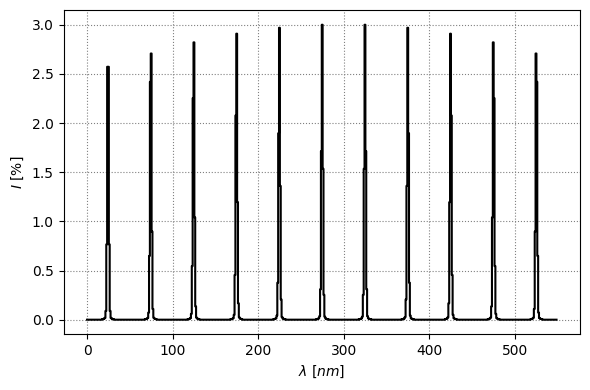

In [3]:
emulation = emulation.setup(
    position=np.array([
    i*N_NUMBERS + position + shift
        for i, shift in enumerate(np.linspace(-.5, +.5, n_peaks, endpoint=False))
    ]),
    concentration=np.full(n_peaks, concentration),
)

spectrum = emulation.run(
    is_noised=False,
    is_clipped=False,
    random_state=42,
)
spectrum.show()


In [4]:
peaks = draft_blinks(
    spectrum=spectrum,
)

In [5]:
shape = retrieve_shape_from_spectrum(
    spectrum=spectrum,
    peaks=peaks,
)

print(shape)

PeakShape(width=2.0002; asymmetry=-0.0001; ratio=0.0991)
